## GPT-01 만들기


[목표] Transformer Decoder를 직접 구현해 대화형 챗봇(next-token prediction) 모델 만들기


##### - Transformer
##### - 사용 환경 : Windows / python 3.12.3 venv


##### 패키지 설치 및 파일 불러오기

##### 맨날 하는 그거입니다

In [7]:
# ===== 외부 패키지 (pip로 설치하는 것들) =====
import numpy as np                    # 숫자 배열 계산 (시드 고정, 통계 등에 사용)
import torch                          # 딥러닝 프레임워크 (텐서, GPU 연산)
import torch.nn as nn                 # 신경망 층(Linear, Embedding 등) 모음
import torch.nn.functional as F       # 활성화 함수, softmax 같은 함수형 API
import torch.optim as optim           # 학습할 때 가중치를 업데이트하는 옵티마이저 (Adam 등)
import matplotlib.pyplot as plt       # 그래프 그리기
import pandas as pd                   # CSV를 표(DataFrame)로 다루는 라이브러리
import sentencepiece as spm           # 문장을 토큰(작은 조각)으로 쪼개는 토크나이저
from torch.utils.data import Dataset, DataLoader  # Dataset: 커스텀 데이터셋 기반 클래스 / DataLoader: 배치로 묶어주는 반복기

# ===== 파이썬 기본 라이브러리 (설치 불필요, 파이썬에 이미 들어 있음) =====
import os                             # 파일/폴더 경로, 환경변수 등 OS 관련 기능
import re                             # 정규표현식 (문자열에서 패턴 찾아 바꾸기)
import sys                            # 파이썬 인터프리터 자체 정보 (표준 출력 stdout 등)
import random                         # 파이썬 기본 난수 (시드 고정용)
import math                            # attention score 스케일링(sqrt)에 사용

import seaborn as sns                 # matplotlib 위에 올린 통계 시각화 (히스토그램이 편함)

from pathlib import Path              # 경로를 문자열 대신 객체로 다루기 (/, expanduser 등)

In [8]:
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
    sys.stderr.reconfigure(encoding="utf-8")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print("device:", device)   # cuda 가 나와야 GPU 가 잘 연결된 것입니다.

csv_path = Path("~/Desktop/아이펠 모음/GPT-0.01/ChatbotData.csv").expanduser()

SEED = 67  # 재현성을 위해 시드 고정
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 한글 폰트 쓰면 마이너스(-) 기호가 깨지는 경우가 있어서 방지

2.14.0+cu126
device: cuda


In [9]:
# CSV를 표 형태(DataFrame)로 읽습니다. 한 행 = 한 대화 쌍, 한 열 = Q/A/label 같은 항목
df = pd.read_csv(csv_path)

print(df.shape)      # (행 개수, 열 개수) 튜플. 데이터가 얼마나 큰지 한눈에 봄
print(df.head())     # 맨 위 5행. 컬럼 이름과 실제 값이 어떻게 생겼는지 확인
print(df.dtypes)     # 각 열이 문자열(object)인지 숫자(int)인지. 잘못 읽히면 여기서 발견

# isnull() : 칸이 비어 있으면 True → sum()으로 열마다 빈칸 개수
print(df.isnull().sum())
# df["label"] : label 열만 꺼냄. value_counts()는 값별로 몇 개인지 세기 (클래스 불균형 확인)
print(df["label"].value_counts())
# duplicated() : 앞 행과 완전히 같은 행이면 True. sum()이면 중복 행 개수
print(df.duplicated().sum())

(11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
Q          str
A          str
label    int64
dtype: object
Q        0
A        0
label    0
dtype: int64
label
0    5290
1    3570
2    2963
Name: count, dtype: int64
0


#### 텍스트 정제(전처리)

In [10]:
def preprocess_korean(sentence):
    """한 문장을 학습하기 좋게 다듬는 함수. 원본 Q/A는 그대로 두고, 깨끗한 복사본을 만듭니다."""
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence


# apply(함수) : 그 열의 각 칸에 함수를 하나씩 적용. for문 돌리는 것과 같음
# 새 열 이름(Q_clean, A_clean)을 만들어서 원본 Q, A는 남겨 둡니다.
df["Q_clean"] = df["Q"].apply(preprocess_korean)
df["A_clean"] = df["A"].apply(preprocess_korean)

# str.len() == 0 인 칸이 True. True를 더하면 빈 문장 개수가 됨
empty_q = (df["Q_clean"].str.len() == 0).sum()
empty_a = (df["A_clean"].str.len() == 0).sum()
print(f"빈 Q: {empty_q}, 빈 A: {empty_a}")

# True인 행만 남김 (Q와 A가 둘 다 글자가 있는 행)
# & 는 "그리고". 두 조건을 동시에 만족해야 함
# reset_index(drop=True) : 중간에 행을 지워서 0,1,4,7처럼 빈 번호가 생기면 0부터 다시 매김
df = df[(df["Q_clean"].str.len() > 0) & (df["A_clean"].str.len() > 0)].reset_index(drop=True)

# subset=[...] : 표 전체가 아니라 지정한 열만 보고 중복인지 판단
dup_count = df.duplicated(subset=["Q_clean", "A_clean"]).sum()
print(f"정제 후 중복: {dup_count}")

빈 Q: 0, 빈 A: 0
정제 후 중복: 73


          Q_wordlen     A_wordlen
count  11823.000000  11823.000000
mean       3.940286      4.715893
std        1.846225      1.924138
min        1.000000      1.000000
25%        3.000000      3.000000
50%        4.000000      4.000000
75%        5.000000      6.000000
max       16.000000     24.000000
저장 완료


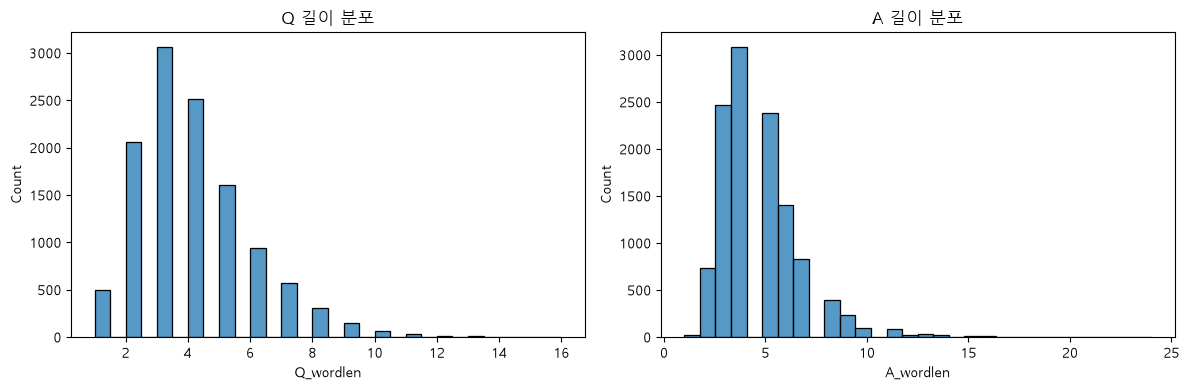

In [11]:
# str.split() : 공백 기준으로 단어 리스트로 나눔  ("안녕 하세요" → ["안녕", "하세요"])
# apply(len) : 그 리스트 길이 = 단어 개수. 문장이 얼마나 긴지 숫자로 만듦
df["Q_wordlen"] = df["Q_clean"].str.split().apply(len)
df["A_wordlen"] = df["A_clean"].str.split().apply(len)

# describe() : 평균, 최소, 최대, 사분위수. 너무 긴 문장이 있는지 볼 때 씀
print(df[["Q_wordlen", "A_wordlen"]].describe())

# subplots(1, 2) : 가로로 그래프 2개. fig=전체 그림, axes=각 칸
# figsize=(가로인치, 세로인치)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histplot : 히스토그램(값의 분포). bins=30은 막대를 30칸으로 나눔
# ax=axes[0] : 왼쪽 칸에 그리기
sns.histplot(df["Q_wordlen"], bins=30, ax=axes[0])
axes[0].set_title("Q 길이 분포")
sns.histplot(df["A_wordlen"], bins=30, ax=axes[1])
axes[1].set_title("A 길이 분포")

plt.tight_layout()                 # 제목/축이 겹치지 않게 여백 조절
plt.savefig("length_dist.png")     # 노트북이 꺼져도 남도록 파일로 저장
print("저장 완료")

In [12]:
# --- corpus.txt 생성 ---
# SentencePiece 학습기는 "한 줄에 문장 하나씩" 들어있는 텍스트 파일을 입력으로 받는다.

def build_corpus(df, columns, save_path):
    """
    지정한 여러 열(columns)의 텍스트를 한 줄씩 모아 하나의 말뭉치 텍스트 파일로 저장한다.

    Args:
        df (pd.DataFrame): Q_clean, A_clean 등 정제된 문장이 들어있는 DataFrame
        columns (list[str]): 말뭉치에 포함할 열 이름. 예: ["Q_clean", "A_clean"]
        save_path (str): 저장할 파일 경로 (예: "corpus.txt")

    Returns:
        int: 저장된 총 줄(문장) 개수

    Example:
        >>> build_corpus(df, ["Q_clean", "A_clean"], "corpus.txt")
        23646
    """
    n_lines = 0
    # [주의] encoding="utf-8"을 안 정하면 Windows(cp949 기본)에서 한글 저장 시 깨지거나 에러 남
    with open(save_path, "w", encoding="utf-8") as f:
        for col in columns:
            for line in df[col]:
                f.write(line + "\n")
                n_lines += 1
    return n_lines


corpus_path = "corpus.txt"
n_lines = build_corpus(df, ["Q_clean", "A_clean"], corpus_path)
print(f"{corpus_path} 생성 완료 (총 {n_lines}줄)")


corpus.txt 생성 완료 (총 23646줄)


#### SentencePiece 토크나이저 학습

In [ ]:
# --- SentencePiece 토크나이저 학습 ---
# GPT는 Q, A를 하나의 시퀀스로 합쳐서 학습하기 때문에
# "여기까지가 질문, 여기부터 답변"을 표시할 <sep> 토큰이 반드시 필요함.
# [주의] 123.py의 seq2seq는 인코더/디코더가 분리돼 있어 <sep>이 필요 없었음 - 구조 차이 주의.

VOCAB_SIZE = 8000   # [주의] 코퍼스 크기에 맞게. 에러 나면 메시지 보고 줄이기 (123.py에서도 겪었던 이슈)

spm.SentencePieceTrainer.train(
    input=corpus_path,
    model_prefix="chatbot_spm",
    vocab_size=VOCAB_SIZE,
    model_type="bpe",                    # BPE: 자주 붙는 글자 쌍을 반복 병합해 subword를 만드는 방식
    pad_id=0, pad_piece="<pad>",
    unk_id=1, unk_piece="<unk>",
    bos_id=2, bos_piece="<bos>",
    eos_id=3, eos_piece="<eos>",
    user_defined_symbols=["<sep>"],      # 기본 제공 토큰이 아니라서 직접 등록해야 함
    normalization_rule_name="identity",  
)
print("토크나이저 학습 완료: chatbot_spm.model, chatbot_spm.vocab 생성됨")


토크나이저 학습 완료: chatbot_spm.model, chatbot_spm.vocab 생성됨


#### 토크나이저 불러오기

In [ ]:
# --- 토크나이저 불러오기 ---
tokenizer = spm.SentencePieceProcessor()
tokenizer.load("chatbot_spm.model")

# 하드코딩 대신 토크나이저에서 직접 가져옴 (vocab이 바뀌어도 코드 깨지지 않음, 123.py와 동일한 이유)
pad_id = tokenizer.pad_id()
bos_id = tokenizer.bos_id()
eos_id = tokenizer.eos_id()
sep_id = tokenizer.piece_to_id("<sep>")   # <sep>은 전용 getter가 없어서 직접 조회

print("vocab size:", tokenizer.get_piece_size())
print("pad/bos/eos/sep id:", pad_id, bos_id, eos_id, sep_id) # unk는 안가져와서 출력 안함


vocab size: 8000
pad/bos/eos/sep id: 0 2 3 4


#### MAX_LEN 결정

In [17]:
# --- 최대 길이 확인 ---
# 123.py와 동일한 방식: 실제 토크나이저 기준 길이를 재서 근거 있게 MAX_LEN을 정함
# (Q_wordlen처럼 띄어쓰기 기준이 아니라, subword 토큰 개수 기준이 정확함)
lengths = [
    len(tokenizer.encode(q)) + len(tokenizer.encode(a)) + 3   # +3 = <bos> <sep> <eos>
    for q, a in zip(df["Q_clean"], df["A_clean"])
]

p95 = np.percentile(lengths, 95)
print(f"상위 95% 지점 길이: {p95:.1f}")

print("최대 길이:", max(lengths), "/ 평균 길이:", sum(lengths) / len(lengths))

# 상위 95%가 21이므로 25로 설정함
# 극단값 때문에 무작정 키우지 말고 평균 근처 + 여유분 정도로 잡는 게 일반적임.
MAX_LEN = 25


상위 95% 지점 길이: 21.0
최대 길이: 43 / 평균 길이: 14.16307197834729


#### Dataset 클래스 정의

In [18]:
# --- Dataset 클래스 정의 ---
# 이전 프로젝트의 TranslationDataset과 같은 원리 (Dataset 상속 -> __len__, __getitem__ 구현해야
# DataLoader가 이 객체를 배치 단위로 순회할 수 있음).
# [주의] 다만 GPT는 인코더/디코더가 분리된 게 아니라 디코더 하나만 쓰기 때문에,
# src/trg를 따로 만들지 않고 <bos> Q <sep> A <eos> 하나의 시퀀스만 다룸.
# 그 시퀀스를 한 칸씩 밀어서 (input, target) 쌍을 만드는 게 GPT류 학습의 핵심 방식임.
class ChatbotDataset(Dataset):
    """
    Q, A 쌍을 <bos> Q <sep> A <eos> 형태의 토큰 ID 시퀀스로 인코딩하고,
    다음 토큰 예측(next-token prediction) 학습에 쓸 (input_ids, target_ids) 쌍을 반환한다.

    Args:
        df (pd.DataFrame): "Q_clean", "A_clean" 열을 가진 DataFrame
        tokenizer (spm.SentencePieceProcessor): 학습된 SentencePiece 토크나이저
        max_len (int): 시퀀스 최대 길이 (bos/sep/eos 포함)

    Returns (__getitem__):
        tuple[torch.Tensor, torch.Tensor]: (input_ids, target_ids), 각각 shape (max_len-1,)

    Example:
        >>> ds = ChatbotDataset(df, tokenizer, max_len=40)
        >>> input_ids, target_ids = ds[0]
    """
    def __init__(self, df, tokenizer, max_len):
        self.q_corpus = df["Q_clean"].tolist()
        self.a_corpus = df["A_clean"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

        # 하드코딩 대신 토크나이저에서 직접 가져옴 (123.py와 동일한 이유)
        self.pad_id = tokenizer.pad_id()
        self.bos_id = tokenizer.bos_id()
        self.eos_id = tokenizer.eos_id()
        self.sep_id = tokenizer.piece_to_id("<sep>")

    def __len__(self):
        # 데이터셋 전체 샘플 개수 반환 (123.py와 동일)
        return len(self.q_corpus)

    def __getitem__(self, idx):
        q_ids = self.tokenizer.encode(self.q_corpus[idx])
        a_ids = self.tokenizer.encode(self.a_corpus[idx])

        # <bos> Q <sep> A <eos> 순서로 하나의 시퀀스로 합침
        ids = [self.bos_id] + q_ids + [self.sep_id] + a_ids + [self.eos_id]

        if len(ids) > self.max_len:
            # [주의] 길이를 초과하면 뒤를 자르되, 마지막은 반드시 <eos>로 끝나게 강제함
            # (안 그러면 "잘린 문장"과 "정상 종료 문장"을 모델이 구분 못 함)
            ids = ids[:self.max_len - 1] + [self.eos_id]
        else:
            ids = ids + [self.pad_id] * (self.max_len - len(ids))

        # GPT 학습은 "한 칸 밀어서 다음 토큰 맞히기" 방식이므로,
        # input_ids = 마지막 토큰 뺀 나머지, target_ids = 첫 토큰 뺀 나머지로 어긋나게 자름
        # 예) ids = [bos, A, sep, B, eos, pad] 라면
        #     input  = [bos, A, sep, B, eos]
        #     target = [A, sep, B, eos, pad]  -> input의 각 위치가 target의 "다음 토큰"을 맞히게 됨
        input_ids = torch.tensor(ids[:-1], dtype=torch.long)
        target_ids = torch.tensor(ids[1:], dtype=torch.long)

        return input_ids, target_ids


# --- Dataset 생성 ---
chatbot_dataset = ChatbotDataset(df, tokenizer, max_len=MAX_LEN)
print(f"Dataset 생성 완료, 샘플 개수: {len(chatbot_dataset)}")

"""
# 작동 확인용 (123.py의 주석 처리된 확인 코드와 동일한 패턴)
input_ids, target_ids = chatbot_dataset[0]
print(input_ids.shape, target_ids.shape)
print("input :", tokenizer.decode(input_ids.tolist()))
print("target:", tokenizer.decode(target_ids.tolist()))
"""


Dataset 생성 완료, 샘플 개수: 11823


'\n# 작동 확인용 (123.py의 주석 처리된 확인 코드와 동일한 패턴)\ninput_ids, target_ids = chatbot_dataset[0]\nprint(input_ids.shape, target_ids.shape)\nprint("input :", tokenizer.decode(input_ids.tolist()))\nprint("target:", tokenizer.decode(target_ids.tolist()))\n'

#### DataLoader

In [21]:
# --- DataLoader ---
# Dataset에서 샘플을 하나씩 꺼내 배치(batch) 단위로 묶어주는 반복기. 123.py와 같은 재료.
BATCH_SIZE = 32   # seq2seq 에서 쓴 값과 동일하게 시작 (무난한 기본값)

train_loader = DataLoader(chatbot_dataset, batch_size=BATCH_SIZE, shuffle=True)


# 작동 확인용
for input_ids, target_ids in train_loader:
    print(input_ids.shape, target_ids.shape)   # 기대: (BATCH_SIZE, MAX_LEN-1) 두 개
    break



torch.Size([32, 24]) torch.Size([32, 24])


#### Transformer Decoder 모델 정의

GPT-1 논문 구조를 따라 4개 조각으로 나눠서 만듭니다.

1. `CausalSelfAttention` — 미래 토큰을 가려서 보는(masked) self-attention
2. `FeedForward` — attention 결과를 한 번 더 비선형 변환
3. `DecoderBlock` — 위 두 개를 residual + LayerNorm으로 감싼 하나의 층
4. `GPTDecoder` — DecoderBlock을 N개 쌓고, Embedding/출력층까지 합친 전체 모델

[주의] Post-LN(잔차 연결 뒤에 LayerNorm) 순서를 씁니다. 원 논문(GPT-1)과 "Attention is All You Need"의
디코더가 이 구조입니다. (참고: GPT-2부터는 학습 안정성을 위해 Pre-LN으로 바뀌었는데, 이건 다른 논문 얘기입니다.)


In [22]:
class CausalSelfAttention(nn.Module):
    """
    미래 토큰을 보지 못하게 가리는(causal masking) Multi-Head Self-Attention.

    Args:
        embed_dim (int): 입력/출력 벡터 차원
        n_heads (int): head 개수. embed_dim은 n_heads로 나누어떨어져야 함
        dropout (float): attention weight에 적용할 dropout 비율

    Returns (forward):
        torch.Tensor: shape (batch, seq_len, embed_dim), 입력과 동일한 shape
    """
    def __init__(self, embed_dim, n_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % n_heads == 0, "embed_dim은 n_heads로 나누어떨어져야 함"
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads

        # Q, K, V를 한 번의 행렬곱으로 같이 projection (따로 3개 Linear 쓰는 것보다 효율적)
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        # x: (batch, seq_len, embed_dim)
        batch_size, seq_len, embed_dim = x.shape

        qkv = self.qkv(x)                         # (batch, seq_len, 3*embed_dim)
        q, k, v = qkv.chunk(3, dim=-1)             # 각각 (batch, seq_len, embed_dim)

        # head별로 나눔: (batch, seq_len, embed_dim) -> (batch, n_heads, seq_len, head_dim)
        # [주의] view 전에 반드시 원래 텐서가 메모리상 연속(contiguous)이어야 함 (chunk 결과는 보통 안전함)
        def split_heads(t):
            t = t.view(batch_size, seq_len, self.n_heads, self.head_dim)
            return t.transpose(1, 2)               # (batch, n_heads, seq_len, head_dim)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # 스케일드 닷프로덕트 어텐션 점수
        attn_scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (batch, n_heads, seq_len, seq_len)

        # causal_mask: (seq_len, seq_len) bool, True=볼 수 있음, False=가려야 함
        # (batch, n_heads, seq_len, seq_len)에 브로드캐스팅으로 그대로 적용됨
        attn_scores = attn_scores.masked_fill(~causal_mask, float("-inf"))

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 나중에 시각화(히트맵)할 때 꺼내 쓰려고 저장해둠. detach()로 연산 그래프에서 분리
        # (안 그러면 시각화 코드가 backward 그래프를 계속 들고 있어 메모리 낭비됨)
        self.last_attn_weights = attn_weights.detach()

        attn_output = attn_weights @ v             # (batch, n_heads, seq_len, head_dim)

        # head들을 다시 하나로 합침: (batch, n_heads, seq_len, head_dim) -> (batch, seq_len, embed_dim)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)

        return self.out_proj(attn_output)


In [23]:
class FeedForward(nn.Module):
    """
    Attention 결과를 한 번 더 비선형 변환하는 position-wise Feed-Forward 층.
    (각 위치(토큰)마다 독립적으로 같은 가중치를 적용 -> "position-wise")

    Args:
        embed_dim (int): 입력/출력 차원
        ff_dim (int): 중간 확장 차원 (보통 embed_dim의 2~4배)
        dropout (float): 출력 dropout 비율

    Returns (forward):
        torch.Tensor: shape (batch, seq_len, embed_dim)
    """
    def __init__(self, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),                    # GPT 계열이 흔히 쓰는 활성화 함수 (ReLU보다 부드러움)
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


In [24]:
class DecoderBlock(nn.Module):
    """
    CausalSelfAttention + FeedForward를 residual 연결과 LayerNorm으로 감싼 하나의 층.
    GPTDecoder는 이 블록을 N_LAYERS개 쌓아서 만듦.

    Args:
        embed_dim (int): 벡터 차원
        n_heads (int): attention head 개수
        ff_dim (int): FeedForward 중간 차원
        dropout (float): dropout 비율

    Returns (forward):
        torch.Tensor: shape (batch, seq_len, embed_dim), 입력과 동일
    """
    def __init__(self, embed_dim, n_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = CausalSelfAttention(embed_dim, n_heads, dropout)
        self.ff = FeedForward(embed_dim, ff_dim, dropout)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        # Post-LN: "입력 + 결과"를 먼저 더하고(residual) 그 다음 LayerNorm (GPT-1 논문 구조)
        attn_out = self.attn(x, causal_mask)
        x = self.ln1(x + self.dropout(attn_out))

        ff_out = self.ff(x)
        x = self.ln2(x + self.dropout(ff_out))

        return x


In [25]:
class GPTDecoder(nn.Module):
    """
    GPT-1 스타일 Decoder-only Transformer. Token Embedding + Positional Embedding
    -> DecoderBlock N개 -> 최종 LayerNorm -> vocab 크기로 projection.

    Args:
        vocab_size (int): 토크나이저 vocab 크기
        max_len (int): 다룰 수 있는 최대 시퀀스 길이 (positional embedding 테이블 크기)
        embed_dim (int): 임베딩 차원
        n_heads (int): attention head 개수
        n_layers (int): DecoderBlock을 쌓을 층 수
        ff_dim (int): FeedForward 중간 차원
        pad_id (int): pad 토큰 ID (embedding에서 항상 0벡터로 고정하기 위해 필요)
        dropout (float): dropout 비율

    Returns (forward):
        torch.Tensor: logits, shape (batch, seq_len, vocab_size)
                      각 위치에서 "다음 토큰"이 vocab 중 무엇일지에 대한 점수
    """
    def __init__(self, vocab_size, max_len, embed_dim, n_heads, n_layers, ff_dim, pad_id, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)   # 학습되는 위치 임베딩 (GPT-1 방식)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DecoderBlock(embed_dim, n_heads, ff_dim, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(embed_dim)          # 마지막 출력을 한 번 더 정규화
        self.head = nn.Linear(embed_dim, vocab_size)  # 최종적으로 vocab 크기 점수로 펼침

        # [주의] register_buffer로 등록하면 model.to(device) 할 때 mask도 같이 GPU로 이동함
        # (반면 그냥 self.mask = ... 로 하면 계속 CPU에 남아서 나중에 디바이스 불일치 에러가 남)
        causal_mask = torch.tril(torch.ones(max_len, max_len)).bool()
        self.register_buffer("causal_mask", causal_mask)

    def forward(self, input_ids):
        # input_ids: (batch, seq_len) - 토큰 ID 정수 시퀀스
        batch_size, seq_len = input_ids.shape

        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)

        x = self.token_embedding(input_ids) + self.pos_embedding(positions)  # (batch, seq_len, embed_dim)
        x = self.dropout(x)

        mask = self.causal_mask[:seq_len, :seq_len]   # 실제 입력 길이만큼만 잘라서 사용

        for block in self.blocks:
            x = block(x, mask)

        x = self.ln_f(x)
        logits = self.head(x)   # (batch, seq_len, vocab_size)
        return logits


#### 하이퍼파라미터 설정 및 모델 생성

In [26]:
# --- 하이퍼파라미터 설정 ---
# 처음부터 크게 잡지 않고, 아래 조합으로 시작 후 필요하면 키우는 걸 추천.
#   EMBED_DIM=256, N_HEADS=4, N_LAYERS=4  -> 가볍게 시작 (아래 기본값)
#   EMBED_DIM=384, N_HEADS=6, N_LAYERS=6  -> 데이터/성능 보고 키울 때 다음 후보
# [주의] GPT-1 원 논문은 12층, embed_dim 768인데, 그건 수십억 단어급 코퍼스 기준이라
#        여기 데이터 규모(11,823문장)엔 그대로 쓰면 과적합만 심해짐.
EMBED_DIM = 256
N_HEADS = 4
N_LAYERS = 4
FF_DIM = 512
DROPOUT = 0.1

model = GPTDecoder(
    vocab_size=tokenizer.get_piece_size(),
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    ff_dim=FF_DIM,
    pad_id=pad_id,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 수: {n_params:,}")

"""
# 작동 확인용: 더미 배치를 하나 통과시켜서 shape이 예상대로 나오는지 확인
sample_input, _ = next(iter(train_loader))
sample_input = sample_input.to(device)
logits = model(sample_input)
print(logits.shape)   # 기대: (BATCH_SIZE, MAX_LEN-1, vocab_size)
"""


총 파라미터 수: 6,219,328


'\n# 작동 확인용: 더미 배치를 하나 통과시켜서 shape이 예상대로 나오는지 확인\nsample_input, _ = next(iter(train_loader))\nsample_input = sample_input.to(device)\nlogits = model(sample_input)\nprint(logits.shape)   # 기대: (BATCH_SIZE, MAX_LEN-1, vocab_size)\n'

#### 학습 루프

RNN 기반이던 123.py의 seq2seq와 달리, GPT(Transformer Decoder)는 시퀀스를 한 스텝씩 순회할 필요가 없습니다.
`model(input_ids)`를 한 번 호출하면 **모든 위치의 다음 토큰 예측을 한 번에** 계산합니다
(각 위치는 causal mask 덕분에 자기 이전 토큰들만 보고 있어서, 병렬로 계산해도 "미리보기"가 안 생김).
그래서 123.py의 `teacher_forcing_ratio` 같은 개념 자체가 필요 없습니다.


In [27]:
# --- 학습 설정 ---
N_EPOCHS = 20
CLIP = 1.0                 # gradient가 튀는 것을 막는 클리핑 (123.py와 동일한 이유)
LEARNING_RATE = 1e-3
CHECKPOINT_PATH = "gpt_checkpoint.pt"   # epoch마다 저장 -> 중단해도 이어서 학습 가능 (123.py와 동일한 패턴)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)   # pad 위치는 애초에 맞고 틀리고를 따질 필요가 없어 loss에서 제외

train_losses = []   # epoch별 평균 loss 기록 (Loss 곡선 시각화에 사용)

# 체크포인트가 있으면 마지막으로 완료된 epoch 다음부터 재개 (123.py와 동일한 패턴)
start_epoch = 1
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    train_losses = ckpt.get("train_losses", [])
    print(f'체크포인트 로드: Epoch {ckpt["epoch"]} (loss {ckpt["avg_loss"]:.4f}) -> Epoch {start_epoch}부터 재개')


In [28]:
# --- 학습 루프 실행 ---
for epoch in range(start_epoch, N_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for input_ids, target_ids in train_loader:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)

        optimizer.zero_grad()
        logits = model(input_ids)   # (batch, seq_len, vocab_size)

        # CrossEntropyLoss는 (N, class) vs (N,) 형태를 기대하므로 배치*시퀀스를 한 줄로 펼침
        loss = criterion(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)   # [주의] step() 하기 전에 clip 먼저
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"[Epoch {epoch:02d}/{N_EPOCHS}] avg loss: {avg_loss:.4f}")

    # epoch 하나 끝날 때마다 체크포인트 저장
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "avg_loss": avg_loss,
        "train_losses": train_losses,
    }, CHECKPOINT_PATH)


[Epoch 01/20] avg loss: 6.2449
[Epoch 02/20] avg loss: 5.4240
[Epoch 03/20] avg loss: 4.6618
[Epoch 04/20] avg loss: 4.0409
[Epoch 05/20] avg loss: 3.5635
[Epoch 06/20] avg loss: 3.1910
[Epoch 07/20] avg loss: 2.8848
[Epoch 08/20] avg loss: 2.6298
[Epoch 09/20] avg loss: 2.4190
[Epoch 10/20] avg loss: 2.2460
[Epoch 11/20] avg loss: 2.1020
[Epoch 12/20] avg loss: 1.9840
[Epoch 13/20] avg loss: 1.8888
[Epoch 14/20] avg loss: 1.8046
[Epoch 15/20] avg loss: 1.7464
[Epoch 16/20] avg loss: 1.6791
[Epoch 17/20] avg loss: 1.6357
[Epoch 18/20] avg loss: 1.5978
[Epoch 19/20] avg loss: 1.5606
[Epoch 20/20] avg loss: 1.5215


#### Loss 곡선 시각화

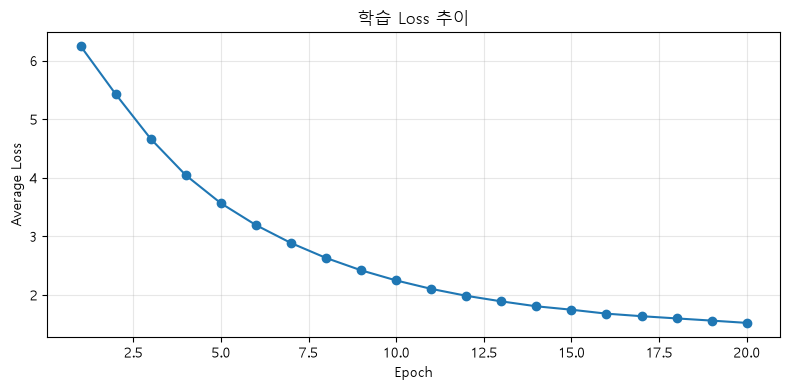

train_loss.png 저장 완료


In [29]:
# --- Loss 곡선 시각화 ---
# loss가 꾸준히 떨어지는지 눈으로 확인. 도중에 평평해지거나 다시 오르면
# LEARNING_RATE, N_LAYERS 등을 조정할 신호로 볼 수 있음.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("학습 Loss 추이")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("train_loss.png")
plt.show()
print("train_loss.png 저장 완료")


#### 생성(추론) 함수

학습된 모델에 질문을 넣으면, `<bos> Q <sep>`까지만 만들어주고 그 뒤는 모델이 한 토큰씩 이어서 채워갑니다.
123.py의 `translate_sentence()`와 같은 역할(greedy decoding)이지만,
인코더가 따로 없어서 "지금까지 만든 전체 시퀀스"를 매번 통째로 다시 모델에 넣는 방식으로 동작합니다.


In [30]:
def generate_response(model, sentence, tokenizer, max_len=None, device=device):
    """
    학습된 GPT 모델에 질문 문장을 넣으면, 한 토큰씩 예측해서 답변을 생성한다 (greedy decoding).

    Args:
        model (GPTDecoder): 학습된 모델
        sentence (str): 입력 질문 (정제 전 원문 가능)
        tokenizer (spm.SentencePieceProcessor): 토크나이저
        max_len (int): 생성 시퀀스 최대 길이. None이면 노트북에서 정한 MAX_LEN 사용
        device (torch.device): 연산 디바이스

    Returns:
        str: 생성된 답변 문자열

    Example:
        >>> generate_response(model, "오늘 기분이 안좋아", tokenizer)
        '''힘내세요 .'''
    """
    if max_len is None:
        max_len = MAX_LEN

    model.eval()

    q_clean = preprocess_korean(sentence)
    q_ids = tokenizer.encode(q_clean)

    # <bos> Q <sep> 까지만 만들고, 그 뒤는 모델이 한 토큰씩 이어서 생성
    input_ids = [bos_id] + q_ids + [sep_id]

    with torch.no_grad():
        for _ in range(max_len - len(input_ids)):
            # [주의] 매 스텝마다 지금까지의 전체 시퀀스를 다시 모델에 넣음 (KV 캐시 없는 가장 단순한 방식이라 느림.
            # 실제 서비스에선 캐시를 써서 매번 새 토큰만 계산하지만, 학습용 과제 범위에서는 이 방식이 이해하기 쉬움)
            src = torch.tensor([input_ids], device=device)     # (1, cur_len)
            logits = model(src)                                 # (1, cur_len, vocab_size)
            next_token_logits = logits[0, -1, :]                # 마지막 위치의 예측만 사용
            next_token = next_token_logits.argmax().item()      # greedy: 확률 제일 높은 토큰 선택

            if next_token == eos_id:
                break
            input_ids.append(next_token)

    # <bos> Q <sep> 뒤에 생성된 답변 부분만 잘라서 디코딩
    sep_pos = input_ids.index(sep_id)
    answer_ids = input_ids[sep_pos + 1:]

    model.train()
    return tokenizer.decode(answer_ids), input_ids


#### 생성 결과 확인

In [ ]:
# --- 생성 결과 확인 ---
# 실제 챗봇 데이터에서 몇 개 뽑아서 답변이 그럴듯한지 확인.
test_questions = ["1지망 학교 떨어졌어", "SNS 맞팔 왜 안하지ㅠㅠ", "3박4일 놀러가고 싶다", "가스불 켜고 나갔어"]

last_ids_for_viz = None   # 바로 다음 셀(attention 시각화)에서 재사용할 시퀀스 하나 저장해둠

for q in test_questions:
    answer, full_ids = generate_response(model, q, tokenizer)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print()
    last_ids_for_viz = full_ids


Q: 1지망 학교 떨어졌어
A: 위로해 드립니다 .

Q: SNS 맞팔 왜 안하지ㅠㅠ
A: SNS 흔적을 가려고 계속 흐르거예요 .

Q: 3박4일 놀러가고 싶다
A: 여행은 언제나 좋죠 .

Q: 가스불 켜고 나갔어
A: 빨리 집에 돌아가서 끄세요 .



#### (보너스) Self-Attention 시각화

여기선 인코더-디코더 사이의
attention이 아니라, **한 시퀀스 안에서 각 토큰이 자기 이전 토큰들 중 어디를 많이 참고했는지**를 봅니다.
행(Query)이 지금 위치, 열(Key)이 "참고한" 위치이고, causal mask 때문에 오른쪽 위 삼각형은 항상 0입니다.


C:\Users\singf\AppData\Local\Temp\ipykernel_7176\4113279830.py:32: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\singf\Desktop\아이펠 모음\Seq2Seq\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


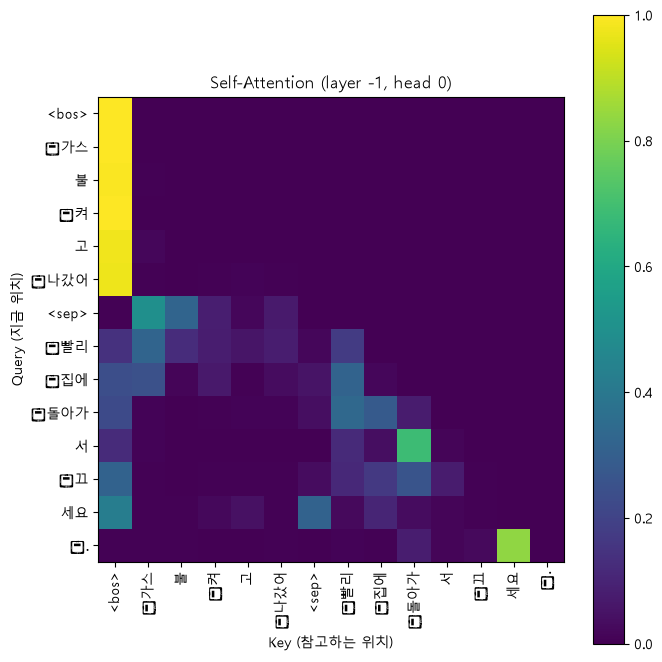

self_attention_map.png 저장 완료


In [32]:
def plot_self_attention(model, input_ids_list, tokenizer, layer=-1, head=0):
    """
    완성된 토큰 시퀀스를 모델에 통과시켜, 지정한 층(layer)/head의 self-attention
    가중치를 히트맵으로 그린다.

    Args:
        model (GPTDecoder): 학습된 모델
        input_ids_list (list[int]): 시각화할 토큰 ID 시퀀스 (<bos>...<eos> 포함)
        tokenizer (spm.SentencePieceProcessor): 토큰 ID -> 문자열 변환용
        layer (int): 몇 번째 DecoderBlock을 볼지 (기본값 -1 = 마지막 층)
        head (int): 몇 번째 attention head를 볼지 (기본값 0)
    """
    model.eval()
    with torch.no_grad():
        src = torch.tensor([input_ids_list], device=device)
        model(src)   # forward 한 번 -> 각 블록의 self.last_attn_weights가 채워짐

    # (batch=1, n_heads, seq_len, seq_len) 중 지정한 head 하나만 꺼내서 numpy로
    attn = model.blocks[layer].attn.last_attn_weights[0, head].cpu().numpy()
    tokens = [tokenizer.id_to_piece(i) for i in input_ids_list]

    fig, ax = plt.subplots(figsize=(max(4, len(tokens) * 0.5), max(4, len(tokens) * 0.5)))
    im = ax.imshow(attn, cmap="viridis")
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens)
    ax.set_xlabel("Key (참고하는 위치)")
    ax.set_ylabel("Query (지금 위치)")
    fig.colorbar(im, ax=ax)
    plt.title(f"Self-Attention (layer {layer}, head {head})")
    plt.tight_layout()
    plt.savefig("self_attention_map.png")
    plt.show()
    print("self_attention_map.png 저장 완료")
    model.train()


# 바로 앞 셀에서 생성한 마지막 문장으로 시각화
if last_ids_for_viz is not None:
    plot_self_attention(model, last_ids_for_viz, tokenizer, layer=-1, head=0)


#### 추가 탐구

##### 그냥 이상한 질문 (줄임말, 오타, 초성 입력 등) 이 해보고 싶었음

In [36]:
test_questions = ["아 살빼야하는데 뭐 시켜먹을까.", "않이 택배 왜 이렇게 안와.... 눙물.... ", "아 집가고 싶다 왜 아직 화요일이지", "im피곤해요.", "아아아 암 픽곤해.","나 우우래."]


for q in test_questions:
    answer, full_ids = generate_response(model, q, tokenizer)
    print(f"Q: {q}")
    print(f"A: {answer}")
    print()
    last_ids_for_viz = full_ids

Q: 아 살빼야하는데 뭐 시켜먹을까.
A: 맛있는 거 드세요 .

Q: 않이 택배 왜 이렇게 안와.... 눙물.... 
A: 복잡한 실수겠네요 .

Q: 아 집가고 싶다 왜 아직 화요일이지
A: 그럴 수 있어요 .

Q: im피곤해요.
A: 떠오르는 시간 보내시길 바랍니다 .

Q: 아아아 암 픽곤해.
A: 스스로를 그만두서 그럴라 , 더 사랑해주세요 .

Q: 나 우우래.
A: 저도 어려운 것 같아요 .



- **데이터 정제**: 특수문자를 과하게 걷어내는 전처리(`[^가-힣0-9?.!, ]`)가 `ㅋㅋ`, `ㅠㅠ`, 영어 단어까지 지워버리는 걸 확인하고, BPE 토크나이저를 쓸 거라 문자 필터링을 최소화하는 쪽으로 방향을 바꿨다.
- **MAX_LEN 결정**: 처음엔 `max()`만 보고 정했는데, 상위 95% 퍼센타일(`np.percentile`)을 보니 21토큰이라 `MAX_LEN=25`로 훨씬 근거 있게 줄일 수 있었다. 극단값 몇 개 때문에 패딩을 낭비할 필요가 없다는 걸 체감함.
- **학습**: `EMBED_DIM=256, N_HEADS=4, N_LAYERS=4`로 가볍게 시작. 20 epoch, loss `6.24 → 1.52`, 소요 시간 2분 30초. 처음엔 너무 빠른 거 아닌가... 싶었는데, 계산해보니 파라미터 수(~600만)와 시퀀스 길이(24토큰)가 GPT-1 원 논문 대비 20배 가까이 작아서 자연스러운 속도였다.
- **아쉬운 점**: 모델이 작아서(4층, 256차원) 표현력의 한계가 있을 수 있음 — loss가 더 안 떨어지면 층 수나 차원을 키워볼 필요. ++ 데이터 갯수와 종류가 너무 아쉽다. 줄임말이나 의도적으로 발음을 뭉개는 경우도 생각했으면 좋았겠다 싶었음.